In [1]:
# Numerical and Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Timing
import time

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load dataset

df = pd.read_csv("spambase_csv.csv")

# Display first five rows
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nInformation:")
df.info()

print("\nSummary Statistics:")
df.describe()

Shape of Dataset:
(4601, 58)

Column Names:
Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu',

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [6]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet         

In [7]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

print(X.shape)

print(y.shape)

(4601, 57)
(4601,)


In [8]:
print(df.head())

print(df.describe())

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0.00          0.0

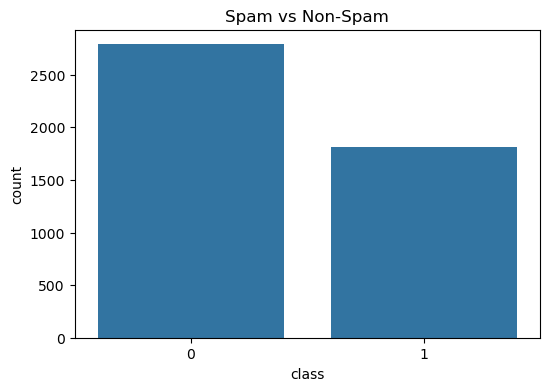

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Spam vs Non-Spam")

plt.show()

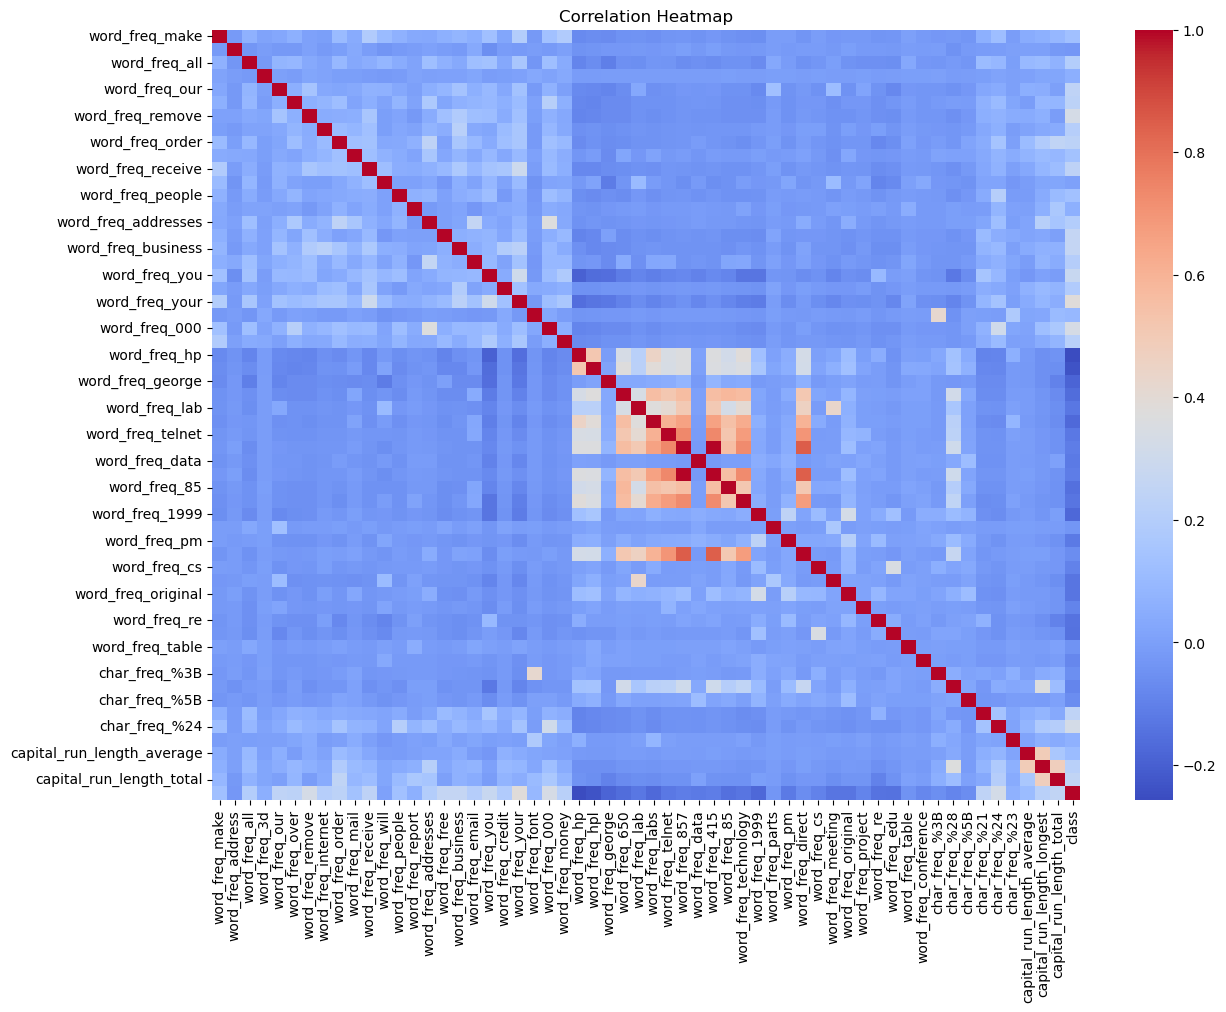

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

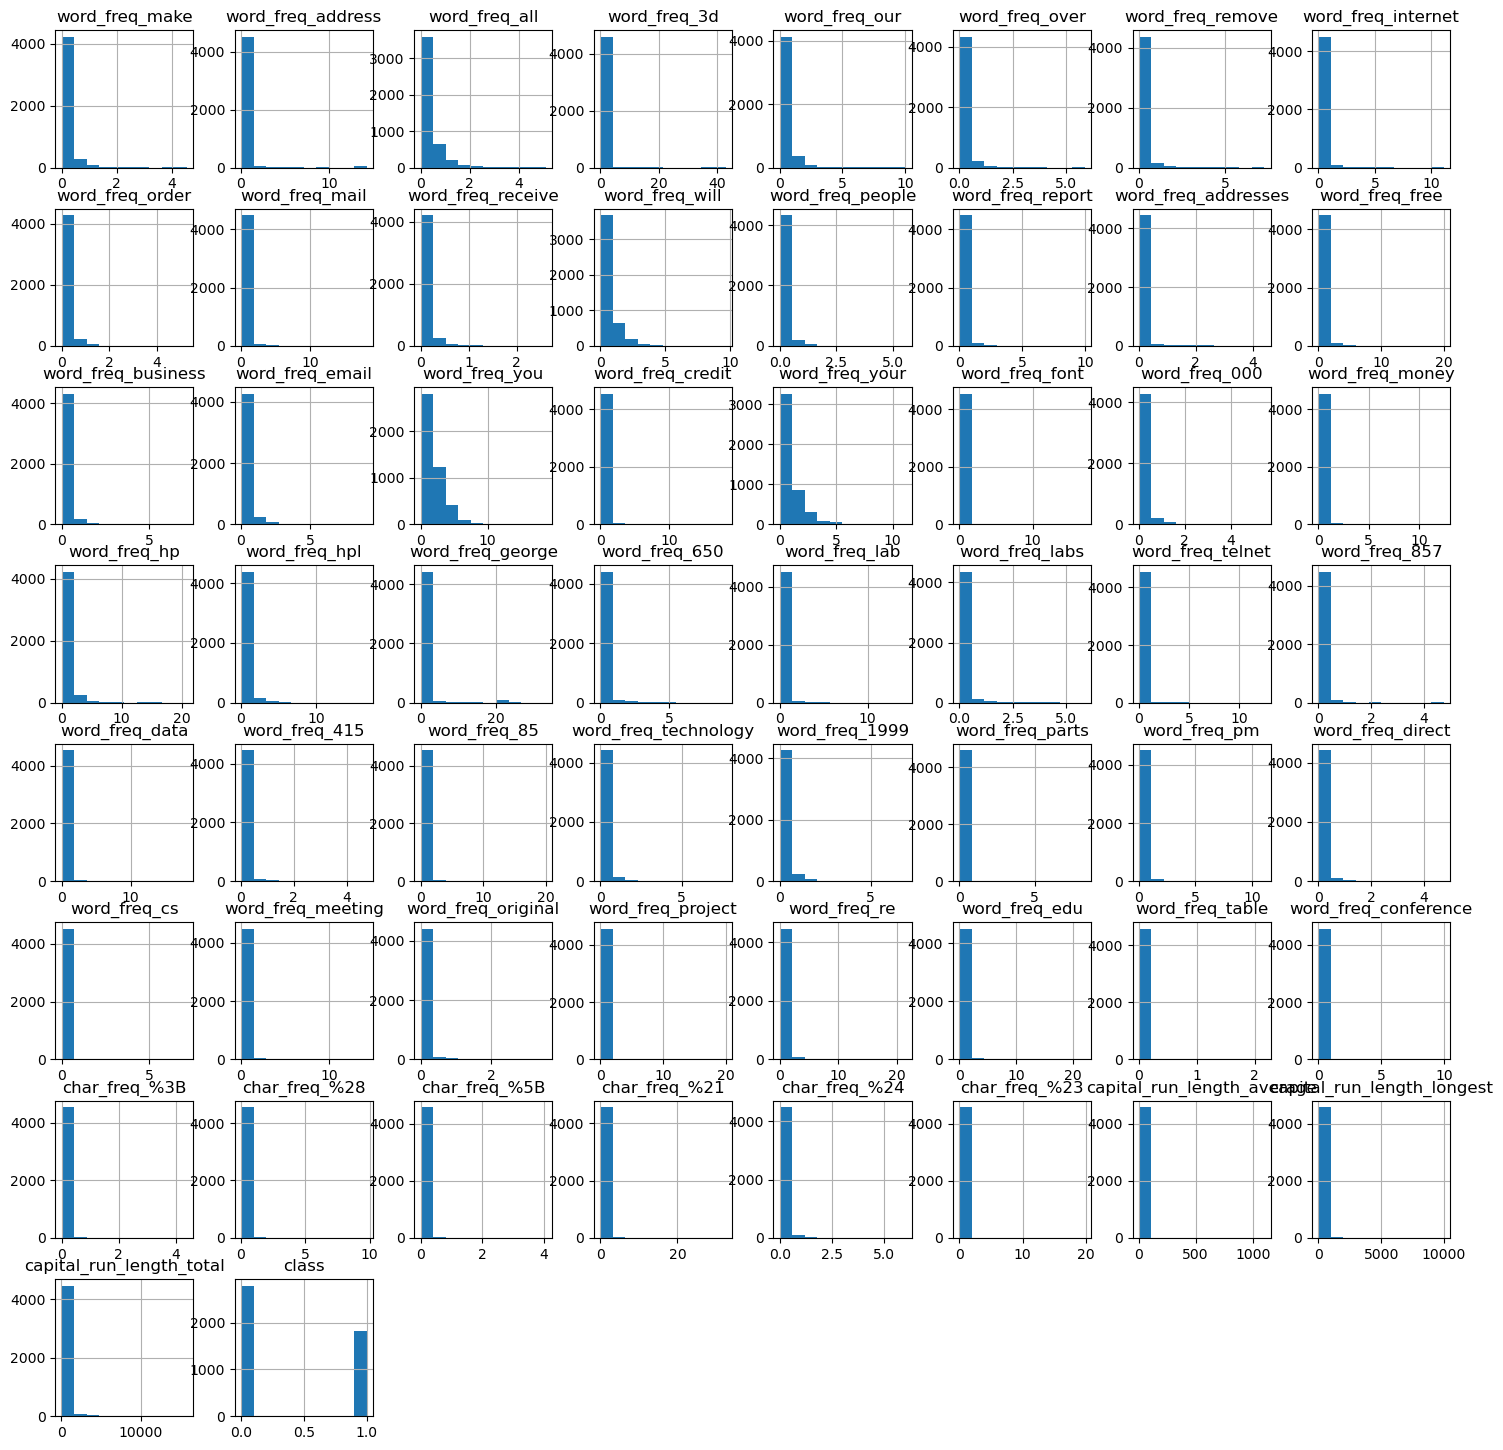

In [11]:
df.hist(figsize=(18,18))

plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(3680, 57)
(921, 57)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
start = time.time()

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

end = time.time()

log_time = end - start

print("Training Time:", log_time)

Training Time: 0.17295551300048828


In [15]:
y_pred = log_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print(classification_report(y_test, y_pred))

Accuracy : 0.9294245385450597
Precision : 0.9209039548022598
Recall : 0.8980716253443526
F1 Score : 0.9093444909344491
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



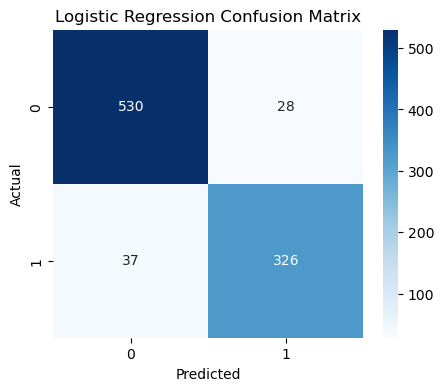

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [17]:
param_grid = {

    "penalty":["l1","l2"],

    "C":[0.01,0.1,1,10,100],

    "solver":["liblinear","saga"]

}

grid_log = GridSearchCV(

    LogisticRegression(),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_log.fit(X_train_scaled,y_train)

print("Best Parameters")

print(grid_log.best_params_)

print("Best CV Accuracy")

print(grid_log.best_score_)

Best Parameters
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy
0.923913043478261


In [18]:
best_log = grid_log.best_estimator_

prediction = best_log.predict(X_test_scaled)

print(classification_report(y_test,prediction))

print("Accuracy :",accuracy_score(y_test,prediction))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.89      0.90       363

    accuracy                           0.93       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.92      0.93      0.92       921

Accuracy : 0.9250814332247557


In [19]:
start=time.time()

svm_linear=SVC(kernel="linear")

svm_linear.fit(X_train_scaled,y_train)

end=time.time()

linear_time=end-start

pred_linear=svm_linear.predict(X_test_scaled)

print("Accuracy")

print(accuracy_score(y_test,pred_linear))

print("F1 Score")

print(f1_score(y_test,pred_linear))

print("Training Time")

print(linear_time)

Accuracy
0.9294245385450597
F1 Score
0.9093444909344491
Training Time
0.46216464042663574


In [20]:
start=time.time()

svm_poly=SVC(kernel="poly")

svm_poly.fit(X_train_scaled,y_train)

end=time.time()

poly_time=end-start

pred_poly=svm_poly.predict(X_test_scaled)

print("Accuracy")

print(accuracy_score(y_test,pred_poly))

print("F1 Score")

print(f1_score(y_test,pred_poly))

print("Training Time")

print(poly_time)

Accuracy
0.7795874049945711
F1 Score
0.6219739292364991
Training Time
0.4603853225708008


In [21]:
start=time.time()

svm_rbf=SVC(kernel="rbf")

svm_rbf.fit(X_train_scaled,y_train)

end=time.time()

rbf_time=end-start

pred_rbf=svm_rbf.predict(X_test_scaled)

print("Accuracy")

print(accuracy_score(y_test,pred_rbf))

print("F1 Score")

print(f1_score(y_test,pred_rbf))

print("Training Time")

print(rbf_time)

Accuracy
0.9272529858849077
F1 Score
0.9055007052186178
Training Time
0.2857067584991455


In [22]:
start=time.time()

svm_sigmoid=SVC(kernel="sigmoid")

svm_sigmoid.fit(X_train_scaled,y_train)

end=time.time()

sigmoid_time=end-start

pred_sigmoid=svm_sigmoid.predict(X_test_scaled)

print("Accuracy")

print(accuracy_score(y_test,pred_sigmoid))

print("F1 Score")

print(f1_score(y_test,pred_sigmoid))

print("Training Time")

print(sigmoid_time)

Accuracy
0.8849077090119435
F1 Score
0.8527777777777777
Training Time
0.292680025100708


In [23]:
param_grid = {

    "kernel":["linear","poly","rbf","sigmoid"],

    "C":[0.1,1,10,100],

    "gamma":["scale","auto"],

    "degree":[2,3,4]

}

grid_svm = GridSearchCV(

    SVC(),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_svm.fit(X_train_scaled,y_train)

print("Best Parameters")

print(grid_svm.best_params_)

print("Best CV Accuracy")

print(grid_svm.best_score_)

Best Parameters
{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy
0.9331521739130435


In [24]:
best_svm = grid_svm.best_estimator_

prediction = best_svm.predict(X_test_scaled)

print(classification_report(y_test,prediction))

print("Accuracy :",accuracy_score(y_test,prediction))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       558
           1       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921

Accuracy : 0.9207383279044516


In [25]:
log_scores = cross_val_score(
    best_log,
    X_train_scaled,
    y_train,
    cv=5
)

svm_scores = cross_val_score(
    best_svm,
    X_train_scaled,
    y_train,
    cv=5
)

print("Logistic Regression Scores")

print(log_scores)

print("Average")

print(log_scores.mean())

print()

print("SVM Scores")

print(svm_scores)

print("Average")

print(svm_scores.mean())

Logistic Regression Scores
[0.94021739 0.91847826 0.91440217 0.91983696 0.92663043]
Average
0.923913043478261

SVM Scores
[0.94293478 0.93206522 0.93342391 0.92119565 0.9361413 ]
Average
0.9331521739130435


In [26]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Linear SVM",
        "Polynomial SVM",
        "RBF SVM",
        "Sigmoid SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test,prediction),
        accuracy_score(y_test,pred_linear),
        accuracy_score(y_test,pred_poly),
        accuracy_score(y_test,pred_rbf),
        accuracy_score(y_test,pred_sigmoid)
    ],

    "F1 Score":[
        f1_score(y_test,prediction),
        f1_score(y_test,pred_linear),
        f1_score(y_test,pred_poly),
        f1_score(y_test,pred_rbf),
        f1_score(y_test,pred_sigmoid)
    ]

})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.920738,0.897616
1,Linear SVM,0.929425,0.909344
2,Polynomial SVM,0.779587,0.621974
3,RBF SVM,0.927253,0.905501
4,Sigmoid SVM,0.884908,0.852778
